In [3]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

d:\Advaned RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Advaned RAG\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Len\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see

True

In [4]:
docs=(
  PyPDFLoader("./documents/machine_learning.pdf").load()
)

In [5]:
len(docs)

718

In [6]:
docs

[Document(metadata={'producer': 'calibre 2.40.0 [http://calibre-ebook.com]', 'creator': 'calibre 2.40.0 [http://calibre-ebook.com]', 'creationdate': '2017-11-22T00:57:36+00:00', 'author': 'Aurélien Géron', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems', 'source': './documents/machine_learning.pdf', 'total_pages': 718, 'page': 0, 'page_label': '1'}, page_content=''),
 Document(metadata={'producer': 'calibre 2.40.0 [http://calibre-ebook.com]', 'creator': 'calibre 2.40.0 [http://calibre-ebook.com]', 'creationdate': '2017-11-22T00:57:36+00:00', 'author': 'Aurélien Géron', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems', 'source': './documents/machine_learning.pdf', 'total_pages': 718, 'page': 1, 'page_label': '2'}, page_content='Hands-On\tMachine\tLearning\twith\tScikit-Learn\nand\tTensorFlow\nConcepts,\tTools,\tand\tTechni

In [7]:
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [8]:
len(chunks)

1716

In [9]:
vector_store = FAISS.from_documents(chunks, embeddings)


In [10]:

vector_store.save_local("vector_store")

In [11]:

retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})


In [12]:
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)

In [13]:

class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [14]:

def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [15]:

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

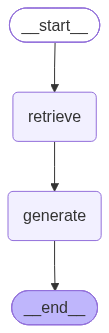

In [16]:

g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [17]:
res = app.invoke({"question": "What is Transformers", "docs": [], "answer": ""})
print(res["answer"])

Based on the context, **Transformers** are estimators (such as an imputer) that can transform a dataset. The transformation is performed by the `transform()` method, which takes the dataset to transform as a parameter and returns the transformed dataset. This process generally relies on learned parameters. Additionally, all transformers have a convenience method called `fit_transform()`, which is equivalent to calling `fit()` and then `transform()`.


In [18]:

print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

(e.g.,	an	
imputer
	is
an	estimator).	The	estimation	itself	is	performed	by	the	
fit()
	method,	and	it	takes	only	a	dataset	as	a	parameter	(or	two
for	supervised	learning	algorithms;	the	second	dataset	contains	the	labels).	Any	other	parameter	needed	to	guide	the
estimation	process	is	considered	a	hyperparameter	(such	as	an	
imputer
’s	
strategy
),	and	it	must	be	set	as	an	instance
variable	(generally	via	a	constructor	parameter).
Transformers
.	Some	
estimators	(such	as	an	
imputer
)	can	also	transform	a	dataset;	these	are	called	
transformers
.	Once
again,	the	API	is	quite	simple:	the	transformation	is	performed	by	the	
transform()
	
method	with	the	dataset	to	transform	as
a	parameter.	It	returns	the	transformed	dataset.	This	transformation	generally	relies	on	the	learned	parameters,	as	is	the
case	for	an	
imputer
.	All	transformers	also	have	a	convenience	method	called
****************************************************************************************************
Custom	Transfo